In [5]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [7]:
import platform, matplotlib as mpl
from matplotlib.font_manager import FontProperties, findfont

def first_ok(cands):
    for name in cands:
        try:
            findfont(FontProperties(family=name), fallback_to_default=False)
            return name
        except Exception:
            pass
    return None

sys = platform.system()
if sys == "Darwin":   # macOS
    cjk_candidates = ["Songti SC", "Hiragino Sans GB", "STHeiti", "PingFang SC",   ]
elif sys == "Windows":
    cjk_candidates = ["Microsoft YaHei", "SimHei", "NSimSun", "KaiTi"]
else:                 # Linux
    cjk_candidates = ["Noto Sans CJK SC", "Source Han Sans SC", "WenQuanYi Micro Hei", "AR PL UMing CN"]

cjk = first_ok(cjk_candidates)

#（可选）清理字体缓存，改完配置后建议重启 kernel
# import shutil; shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)

mpl.rcParams.update({
    # 关键顺序：STIX（英文/数学） → DejaVu Sans（含 U+2212） → 中文
    "font.family": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),
    "font.sans-serif": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),

    # 数学字体固定用 STIX，防止落到“default”
    "mathtext.fontset": "stix",
    "mathtext.rm": "STIXGeneral",
    "mathtext.it": "STIXGeneral:italic",
    "mathtext.bf": "STIXGeneral:bold",

    "axes.unicode_minus": True,   # 使用 Unicode '−'（由 STIX/DejaVu 提供）
    "text.usetex": False,         # 没有配置 CJK 的 LaTeX 时必须关闭
    'font.size': 16, 
})
#print("CJK fallback:", cjk or "未找到；建议安装 Noto Sans CJK / 思源黑体 / 微软雅黑 / 苹方")

##====== 放大显示的字体
from IPython.display import HTML
HTML("""
<style>
/* —— JupyterLab 渲染后的 Markdown —— */
.jp-MarkdownCell .jp-RenderedHTMLCommon {
  font-size: 1.20em;          /* 整体放大 20% */
  line-height: 1.6;
}

/* 可选：调大标题层级（按需调） */
.jp-MarkdownCell h1 { font-size: 1.9em; }
.jp-MarkdownCell h2 { font-size: 1.6em; }
.jp-MarkdownCell h3 { font-size: 1.35em; }

/* 可选：渲染公式（MathJax v3）一起放大 */
.mjx-container { font-size: 115% !important; }
</style>
""")

In [9]:
import numpy as np
import math
import matplotlib.pyplot as plt

# 牛顿迭代法（Newton’s method）

In [56]:
def numdiff1(f, x, h=1e-6):
    """简单中心差分近似导数 f'(x) ≈ [f(x+h)-f(x-h)]/(2h)"""
    return (f(x + h) - f(x - h)) / (2.0 * h)

def newton_1d(f, df=None, x0=0.0, tol_x=1e-12, tol_f=1e-12, maxit=50,
              damping=True, ls_max=8, verbose=False):
    """
    一维牛顿法：
      - f: 目标函数
      - df: 导数函数；若为 None，使用数值导数 numdiff1
      - damping: 是否启用简单线搜索（回溯）阻尼，避免“越走越差”
      - 返回 root, history（每步记录 x, f, step）
    """
    if df is None:
        df = lambda x: numdiff1(f, x)

    x = float(x0)
    fx = f(x)
    hist = [{"k": 0, "x": x, "f": fx, "step": np.nan}]

    if abs(fx) <= tol_f:
        return x, hist

    for k in range(1, maxit + 1):
        dfx = df(x)
        if dfx == 0.0 or not np.isfinite(dfx):
            # 导数为0或数值不稳定：直接返回，或在外部兜底
            if verbose: print(f"[k={k}] derivative ~ 0, abort")
            return x, hist

        # 牛顿步（未阻尼）
        step = - fx / dfx

        # 阻尼/回溯：若 |f(x+step)| 没有变小，则衰减步长
        lam = 1.0
        x_new = x + lam * step
        f_new = f(x_new)
        if damping:
            # 简单 Armijo 风格：要求 |f| 减小
            cnt = 0
            while abs(f_new) >= abs(fx) and cnt < ls_max:
                lam *= 0.5
                x_new = x + lam * step
                f_new = f(x_new)
                cnt += 1

        hist.append({"k": k, "x": x_new, "f": f_new, "step": lam*step})

        # 停机
        if abs(f_new) <= tol_f or abs(x_new - x) <= tol_x:
            return x_new, hist

        x, fx = x_new, f_new

    return x, hist

def extract_series(history):
    k = np.array([h["k"] for h in history])
    xs = np.array([h["x"] for h in history], dtype=float)
    fs = np.array([h["f"] for h in history], dtype=float)
    st = np.array([h["step"] for h in history], dtype=float)
    return k, xs, fs, st


In [58]:
def plot_geometry(f, hist, x_view=None, title=None, n_lines=6):
    if x_view is None:
        xs_hist = [h["x"] for h in hist]
        lo = min(xs_hist) - 1.0
        hi = max(xs_hist) + 1.0
        x_view = (lo, hi)

    xs = np.linspace(*x_view, 600)
    ys = np.array([f(x) for x in xs])

    plt.figure(figsize=(9, 7))
    plt.axhline(0.0, color='k', linewidth=1)
    plt.plot(xs, ys, label="f(x)")

    # 画前几步的切线
    cnt = min(n_lines, len(hist)-1)
    for i in range(0, cnt):
        xk = hist[i]["x"]
        fx = hist[i]["f"]
        # 数值导数仅用于可视化（若 df 已提供不会影响收敛）
        slope = (f(xk+1e-6) - f(xk-1e-6)) / (2e-6)
        # 切线 y = f(xk) + slope*(x-xk)
        yL = fx + slope*(xs[0]-xk)
        yR = fx + slope*(xs[-1]-xk)
        plt.plot([xs[0], xs[-1]], [yL, yR], linestyle="--", alpha=0.6)

    # 标注迭代点
    xs_hist = [h["x"] for h in hist]
    fs_hist = [h["f"] for h in hist]
    plt.scatter(xs_hist, fs_hist, s=50, zorder=3, label="iterations")
    plt.scatter([xs_hist[-1]], [fs_hist[-1]], marker="x", s=120, label="final")

    plt.title(title if title else "Newton geometry (tangent intersections)")
    plt.xlabel("x"); plt.ylabel("f(x)")
    plt.legend(); plt.tight_layout(); plt.show()


2. 求方程 $x - e^{-x} = 0$ 在区间 $(0,\,1)$ 内的根。

In [60]:
# 定义方程
def f1(x):
    return x - np.exp(-x)

def df1(x):
    return 1 + np.exp(-x)

In [62]:
x_ref, hist_ref = newton_1d(f1, df=df1, x0=0.5, tol_x=1e-14, tol_f=1e-14, maxit=100, damping=False)
print(f"参考根 ≈ {x_ref:.16f}, f(x*)={f1(x_ref):.3e}")


参考根 ≈ 0.5671432904097811, f(x*)=-4.441e-15


牛顿结果 ≈ 0.567143290410, f(root)=-4.441e-15, 迭代步数=4


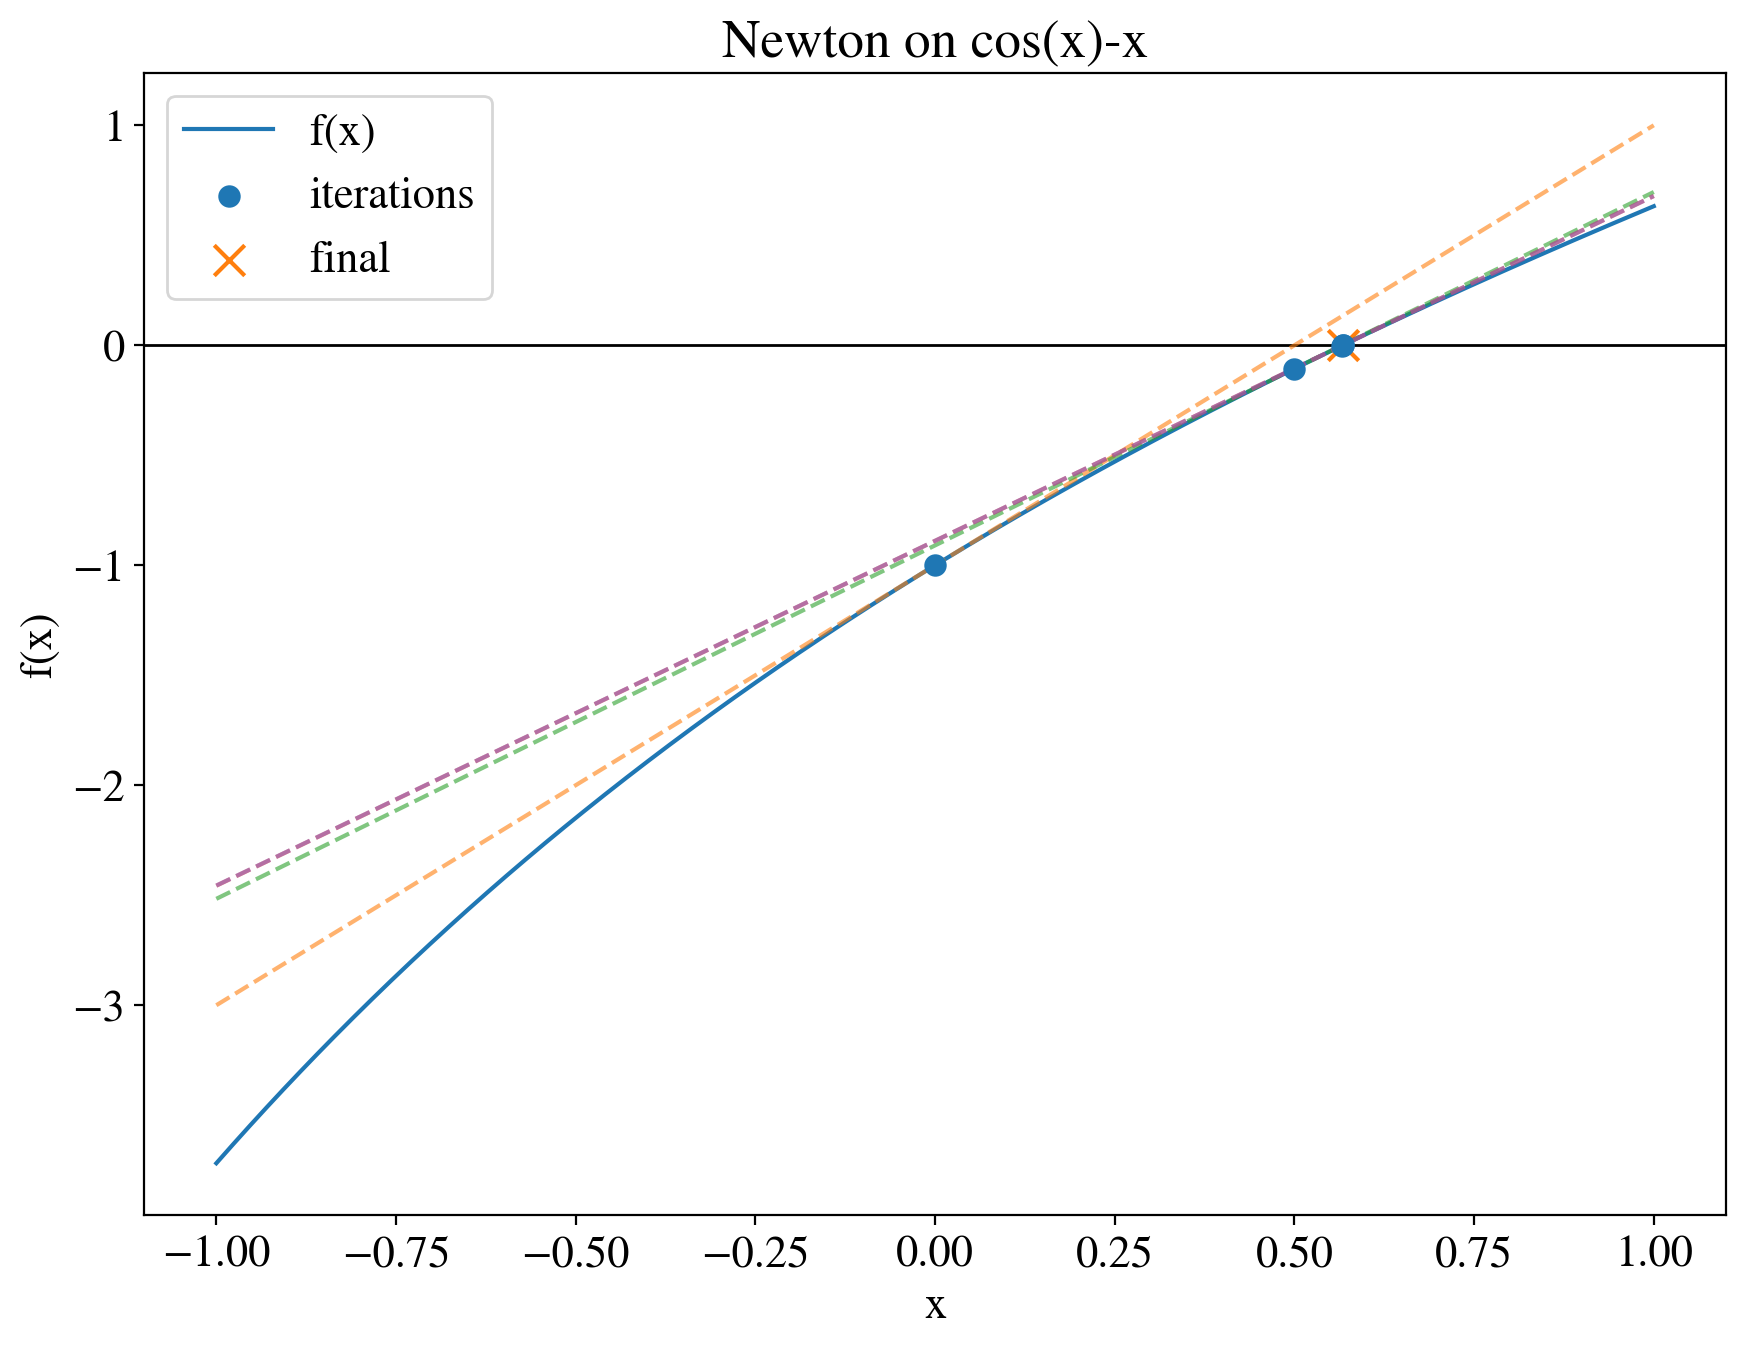

In [65]:
import math

# 正式演示：从较普通初值出发
root, hist = newton_1d(f1, df=df1, x0=0.0, tol_x=1e-12, tol_f=1e-12, maxit=30, damping=False)
print(f"牛顿结果 ≈ {root:.12f}, f(root)={f1(root):.3e}, 迭代步数={len(hist)-1}")

# 可视化
plot_geometry(f1, hist, x_view=(-1.0,1.0), title="Newton on cos(x)-x")


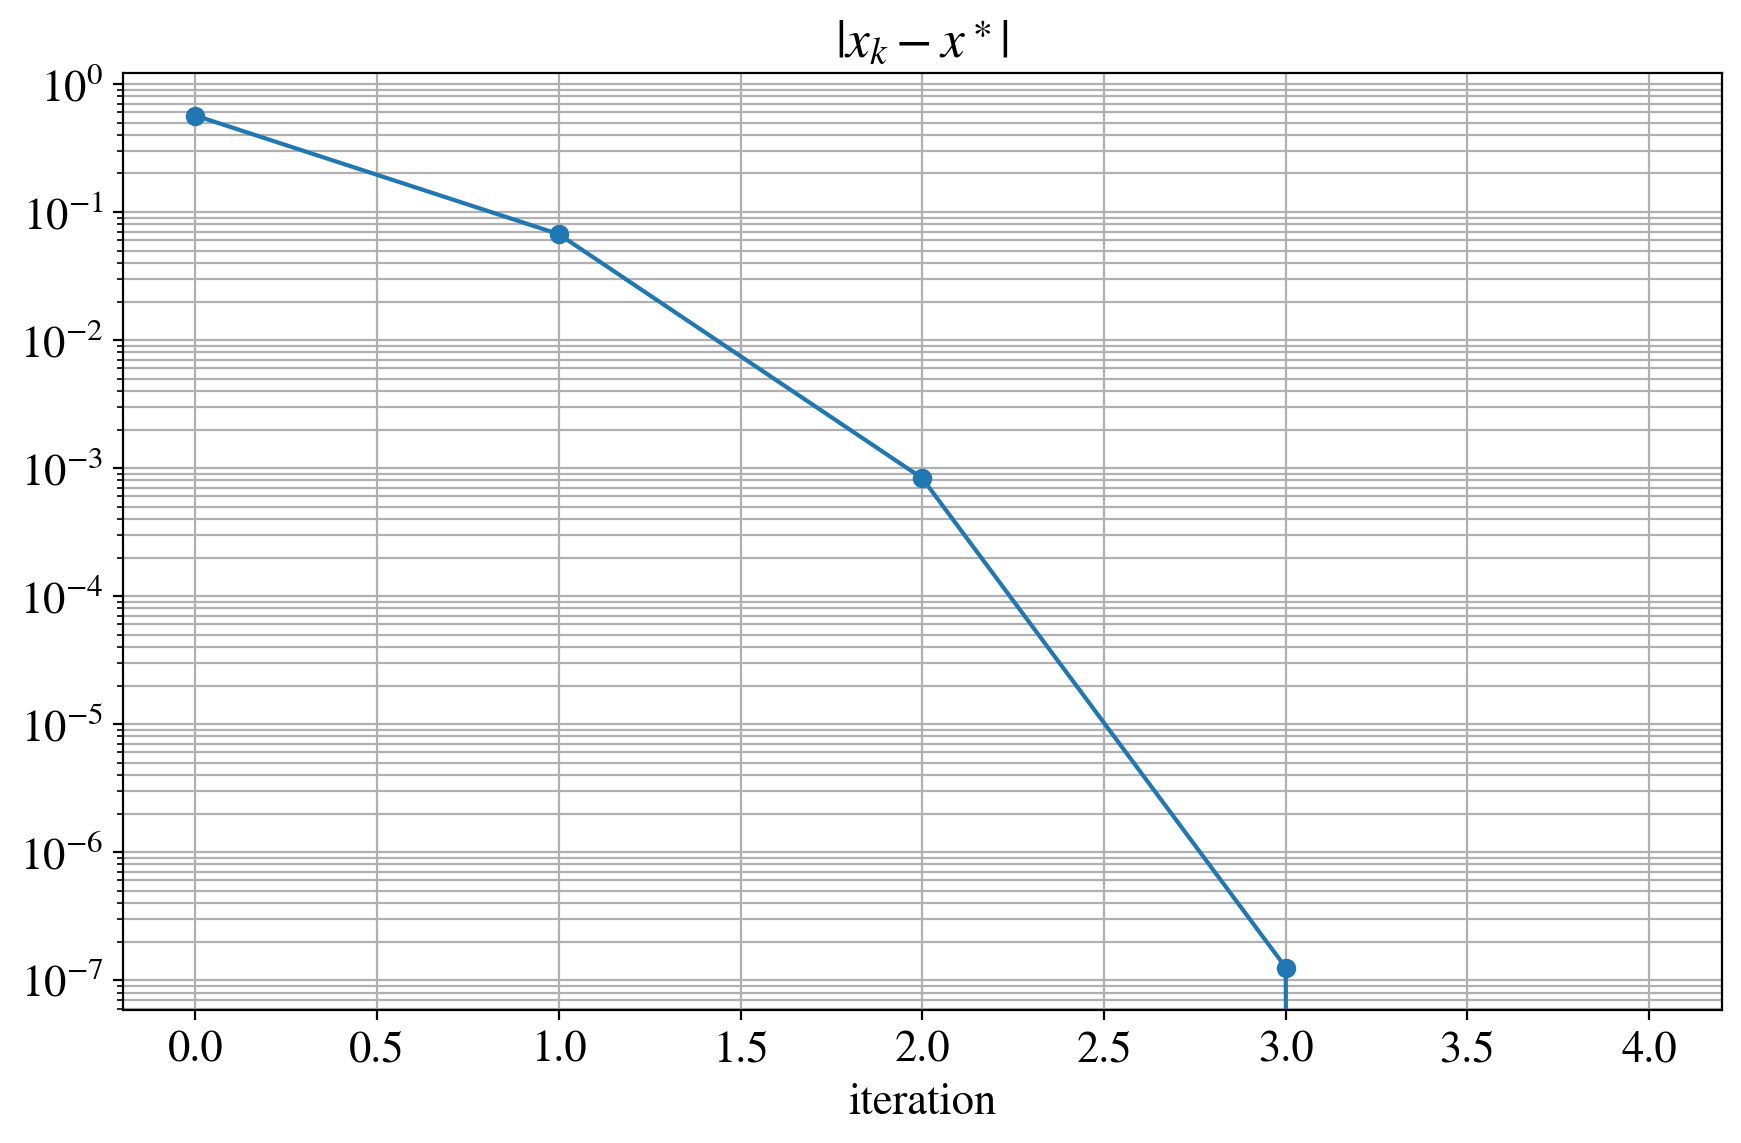

In [67]:
k, xs, fs, st = extract_series(hist)

fig, ax = plt.subplots(1,1,figsize=(9, 6))

ax.semilogy(k, np.abs(xs - x_ref), marker='o')

ax.set_title(r"$|x_k - x^\ast|$")
ax.set_xlabel("iteration")
ax.grid(True, which='both')

plt.tight_layout()
plt.show()


## 课堂练习
$$
\begin{cases}
x - 0.7 \sin x - 0.2 \cos y = 0 \\
y - 0.7 \cos x + 0.2 \sin y = 0
\end{cases}
$$


=== 初始值 [0.5 0.5] ===
解: [0.52652262 0.50791972]
F(解) = [3.05311332e-16 2.77555756e-16]
残差范数: 4.13e-16
迭代步数: 3

=== 初始值 [1. 1.] ===
解: [0.52652262 0.50791972]
F(解) = [-2.77555756e-17  5.55111512e-17]
残差范数: 6.21e-17
迭代步数: 5

=== 初始值 [0. 0.] ===
解: [0.52652262 0.50791972]
F(解) = [-2.77555756e-17  5.55111512e-17]
残差范数: 6.21e-17
迭代步数: 5

=== 初始值 [-0.5 -0.5] ===
解: [0.52652262 0.50791972]
F(解) = [2.05391260e-14 3.33205685e-14]
残差范数: 3.91e-14
迭代步数: 5


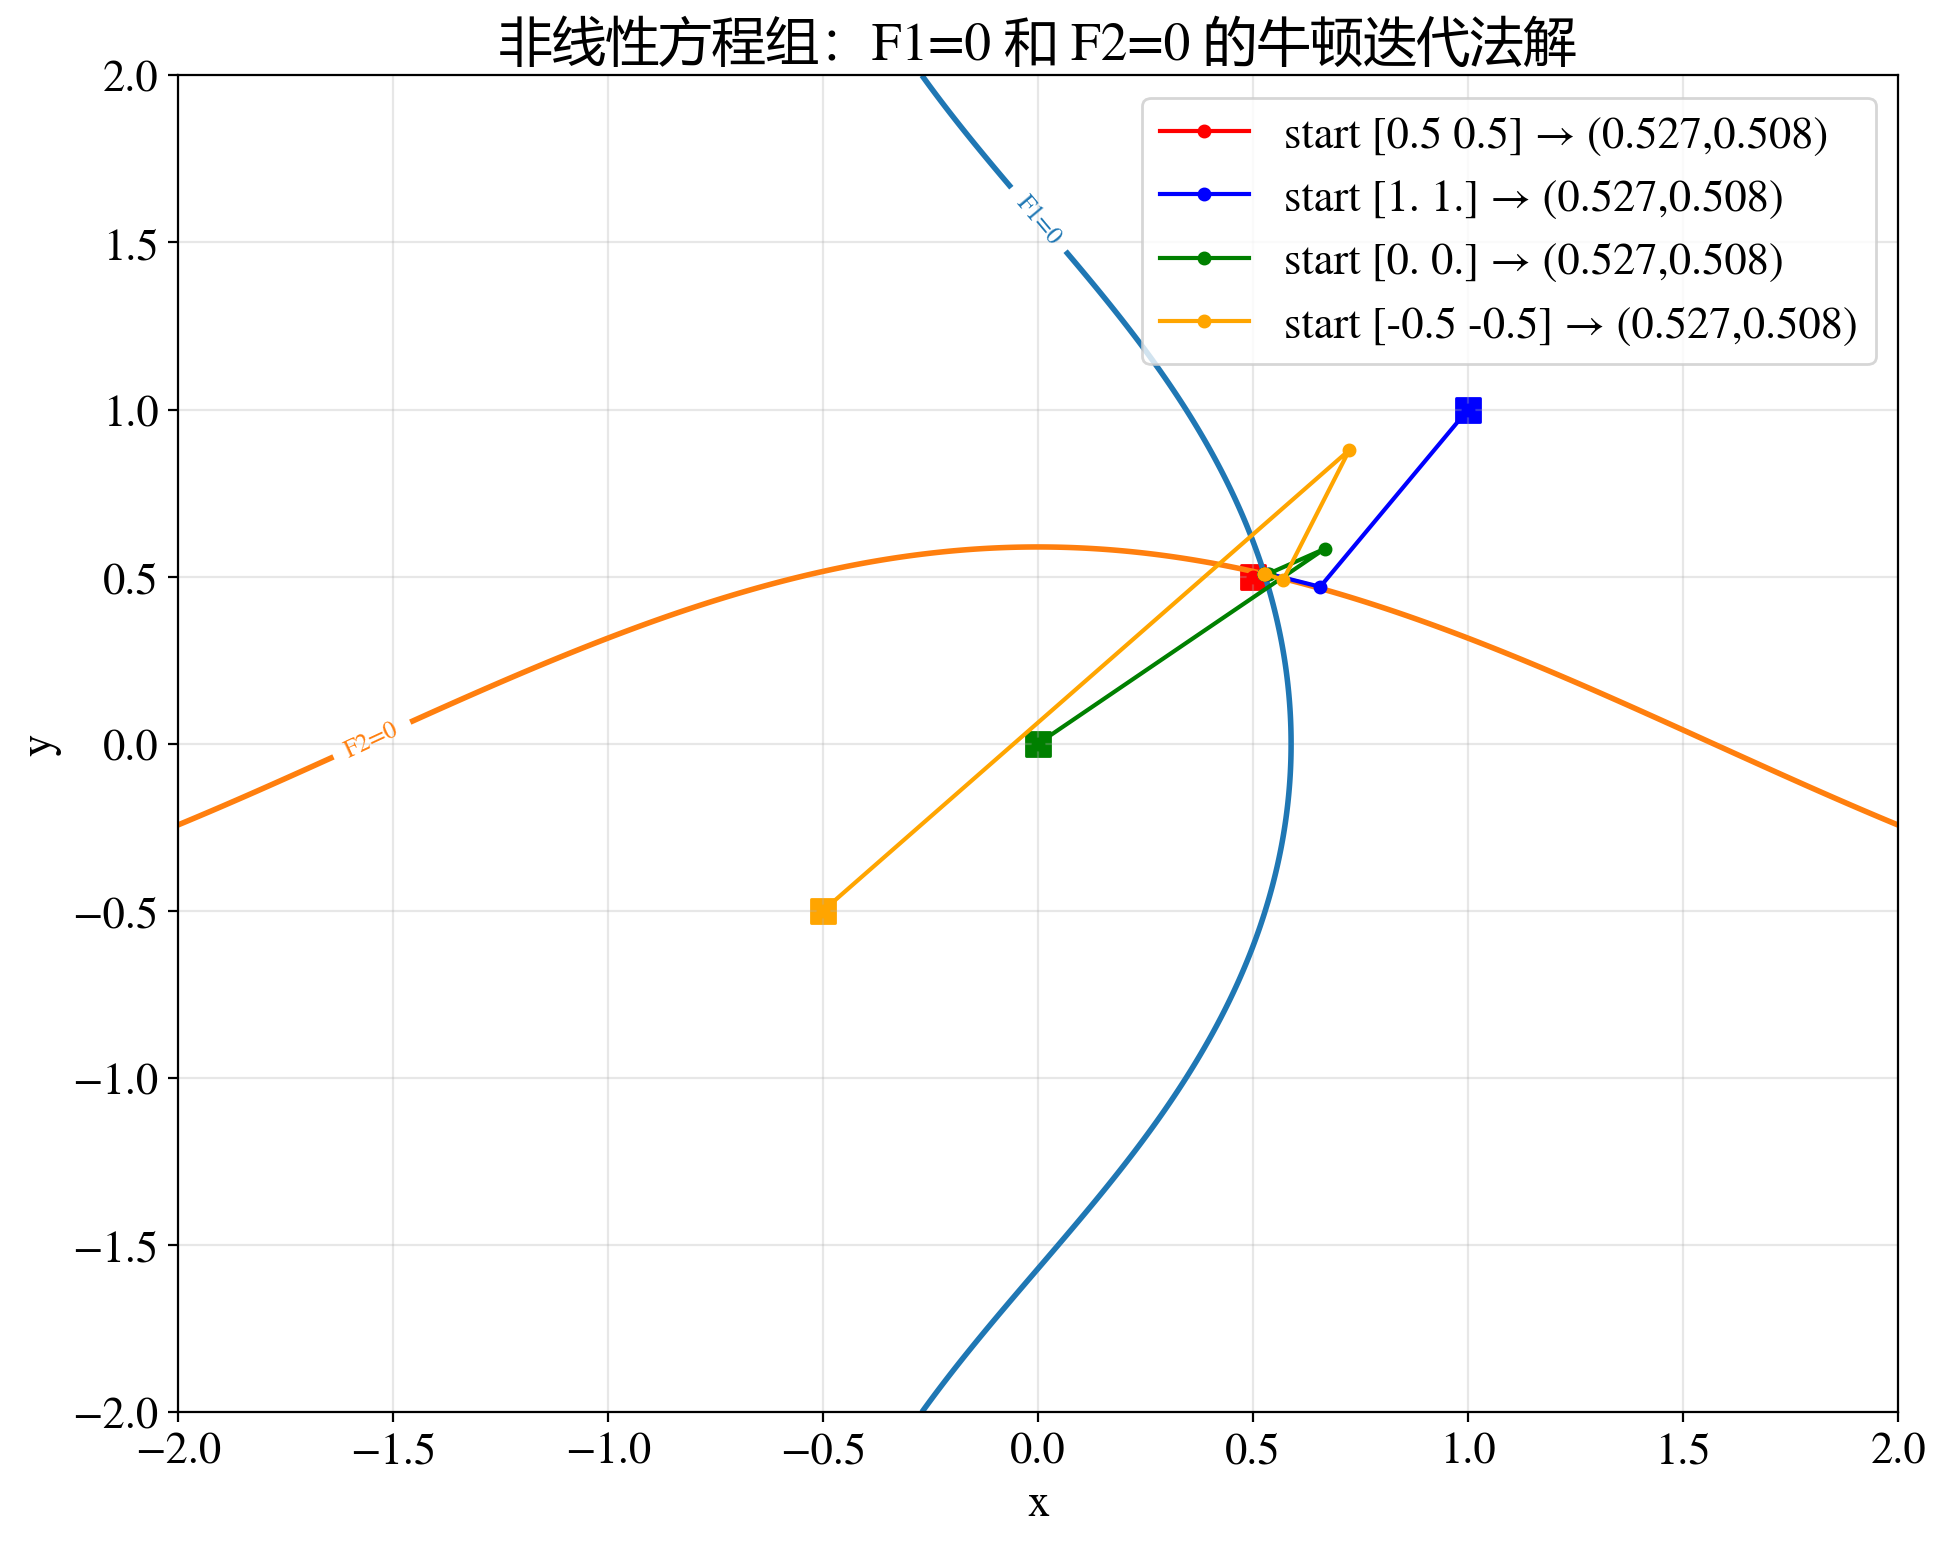

In [71]:
import numpy as np
import matplotlib.pyplot as plt

def F3_fn(vec):
    x, y = vec
    return np.array([
        x - 0.7 * np.sin(x) - 0.2 * np.cos(y),    # F1
        y - 0.7 * np.cos(x) + 0.2 * np.sin(y)     # F2
    ], dtype=float)

def J3_fn(vec):
    x, y = vec
    return np.array([
        [1 - 0.7 * np.cos(x), 0.2 * np.sin(y)],    ## [dF1/dx, dF1/dy]
        [0.7 * np.sin(x), 1 + 0.2 * np.cos(y)]     ## [dF2/dx, dF2/dy]
    ], dtype=float)

# 阻尼牛顿法
def newton_system(F, J, x0, tol_f=1e-12, tol_x=1e-12, maxit=50,
                  damping=True, alpha=1e-4, beta=0.5, ls_max=10):
    """ 
    F: R^n -> R^n
    J: R^n -> R^n (n x n) (解析或数值雅可比)
    x0: 初值 (np.array)
    damping: 是否线搜索阻尼 (Armijo风格)
    alpha: Armijo参数 (0<alpha<1), 控制"足够下降"的阈值
    beta: 回溯因子 (0<beta<1)
    返回: x, history
    """ 
    x = np.array(x0, dtype=float)
    r = F(x)
    hist = [{"k":0, "x":x.copy(), "F":r.copy(), "normF":np.linalg.norm(r)}]
    
    if np.linalg.norm(r) <= tol_f:
        return x, hist
    
    for k in range(1, maxit+1):
        Jx = J(x)
        try:
            # 解 J Δ = -F
            delta = np.linalg.solve(Jx, -r)
        except np.linalg.LinAlgError:
            # 雅可比病态或者奇异：回退到最小二乘意义下的解
            delta, *_ = np.linalg.lstsq(Jx, -r, rcond=None)
        
        # 阻尼/回溯线搜索（若启用）
        lam = 1.0
        x_new = x + lam * delta
        r_new = F(x_new)
        
        if damping:
            # 目标函数: phi(x) = 0.5 * ||F(x)||^2
            phi0 = 0.5 * np.dot(r, r)
            # 一阶预测下降量（近似）: -alpha * lam * ||F||^2 （简单选择）
            cnt = 0
            while 0.5 * np.dot(r_new, r_new) > (1 - alpha * lam) * phi0 and cnt < ls_max:
                lam *= beta
                x_new = x + lam * delta
                r_new = F(x_new)
                cnt += 1
        
        # 记录
        hist.append({"k":k, "x":x_new.copy(), "F":r_new.copy(), "normF":np.linalg.norm(r_new),
                    "lam":lam, "step_norm":np.linalg.norm(lam * delta)})
        
        # 停止判断
        if np.linalg.norm(r_new) <= tol_f: # 残差足够小
            return x_new, hist
        if np.linalg.norm(lam * delta) <= tol_x: # 步长足够小
            return x_new, hist
        
        # 推进
        x, r = x_new, r_new
    
    return x, hist

# --- 运行求解 ---
# 尝试不同的初始值
x0_list = [
    np.array([0.5, 0.5]),
    np.array([1.0, 1.0]),
    np.array([0.0, 0.0]),
    np.array([-0.5, -0.5])
]

for i, x0 in enumerate(x0_list):
    print(f"\n=== 初始值 {x0} ===")
    sol, hist = newton_system(F3_fn, J3_fn, x0, tol_f=1e-12, tol_x=1e-12, 
                             maxit=30, damping=True, alpha=1e-4, beta=0.5, ls_max=8)
    
    print(f"解: {sol}")
    print(f"F(解) = {F_fn(sol)}")
    print(f"残差范数: {np.linalg.norm(F_fn(sol)):.2e}")
    print(f"迭代步数: {len(hist)-1}")

# --- 可视化：等高线 + 迭代轨迹 ---
# 画 F1=0 与 F2=0 的等高线
xx = np.linspace(-2, 2, 400)
yy = np.linspace(-2, 2, 400)
XX, YY = np.meshgrid(xx, yy)

F1 = XX - 0.7 * np.sin(XX) - 0.2 * np.cos(YY)    # F1
F2 = YY - 0.7 * np.cos(XX) + 0.2 * np.sin(YY)    # F2

plt.figure(figsize=(10, 8))
cs1 = plt.contour(XX, YY, F1, levels=[0.0], colors='C0', linewidths=2)
cs2 = plt.contour(XX, YY, F2, levels=[0.0], colors='C1', linewidths=2)

plt.clabel(cs1, inline=True, fmt='F1=0', fontsize=9)
plt.clabel(cs2, inline=True, fmt='F2=0', fontsize=9)

# 绘制不同初始值的迭代轨迹
colors = ['red', 'blue', 'green', 'orange']
for i, x0 in enumerate(x0_list):
    sol, hist = newton_system(F_fn, J_fn, x0, tol_f=1e-12, tol_x=1e-12, 
                             maxit=30, damping=True, alpha=1e-4, beta=0.5, ls_max=8)
    
    xy = np.array([h["x"] for h in hist])
    plt.plot(xy[:,0], xy[:,1], '-o', ms=4, lw=1.5, color=colors[i], 
             label=f'start {x0} → ({sol[0]:.3f},{sol[1]:.3f})')
    plt.scatter([xy[0,0]], [xy[0,1]], c=colors[i], s=80, marker='s')

plt.xlabel("x")
plt.ylabel("y")
plt.title("非线性方程组：F1=0 和 F2=0 的牛顿迭代法解")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [69]:
# --- 收敛性分析 ---
print("\n=== 收敛性分析 ===")
x0 = np.array([0.5, 0.5])
sol, hist = newton_system(F_fn, J_fn, x0, tol_f=1e-12, tol_x=1e-12, 
                         maxit=30, damping=True, alpha=1e-4, beta=0.5, ls_max=8)

print("迭代历史:")
print("k\tx\ty\t||F||\t步长\tλ")
for h in hist:
    print(f"{h['k']}\t{h['x'][0]:.6f}\t{h['x'][1]:.6f}\t{h['normF']:.2e}\t{h.get('step_norm', 0):.2e}\t{h.get('lam', 1):.3f}")


=== 收敛性分析 ===
迭代历史:
k	x	y	||F||	步长	λ
0	0.500000	0.500000	2.15e-02	0.00e+00	1.000
1	0.526824	0.508014	2.52e-04	2.80e-02	1.000
2	0.526523	0.507920	3.19e-08	3.16e-04	1.000
3	0.526523	0.507920	4.13e-16	4.13e-08	1.000


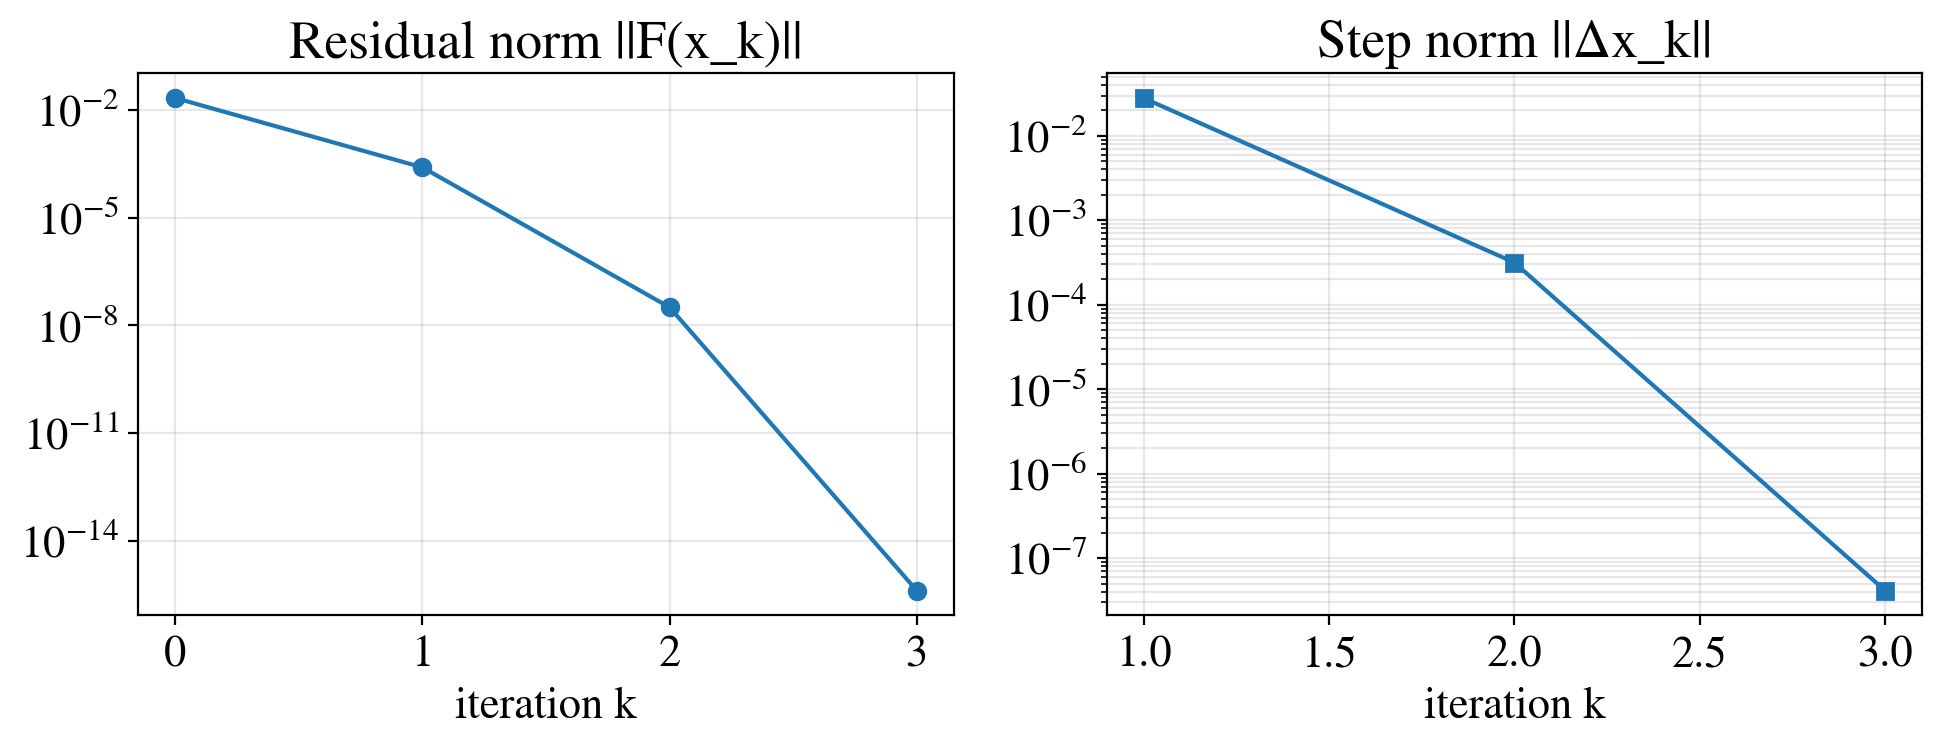

In [15]:

# ---------- 收敛曲线 ----------
normF = [h["normF"] for h in hist]
stepN = [np.nan] + [h.get("step_norm", np.nan) for h in hist[1:]]

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].semilogy(normF, marker='o')
ax[0].set_title("Residual norm ||F(x_k)||")
ax[0].set_xlabel("iteration k")
ax[0].grid(True, which='both', alpha=0.3)

ax[1].semilogy(stepN, marker='s')
ax[1].set_title("Step norm ||Δx_k||")
ax[1].set_xlabel("iteration k")
ax[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

解: [0.52652262 0.50791972]
F(解) = [3.05311332e-16 2.77555756e-16]
残差范数: 4.13e-16
迭代步数: 3


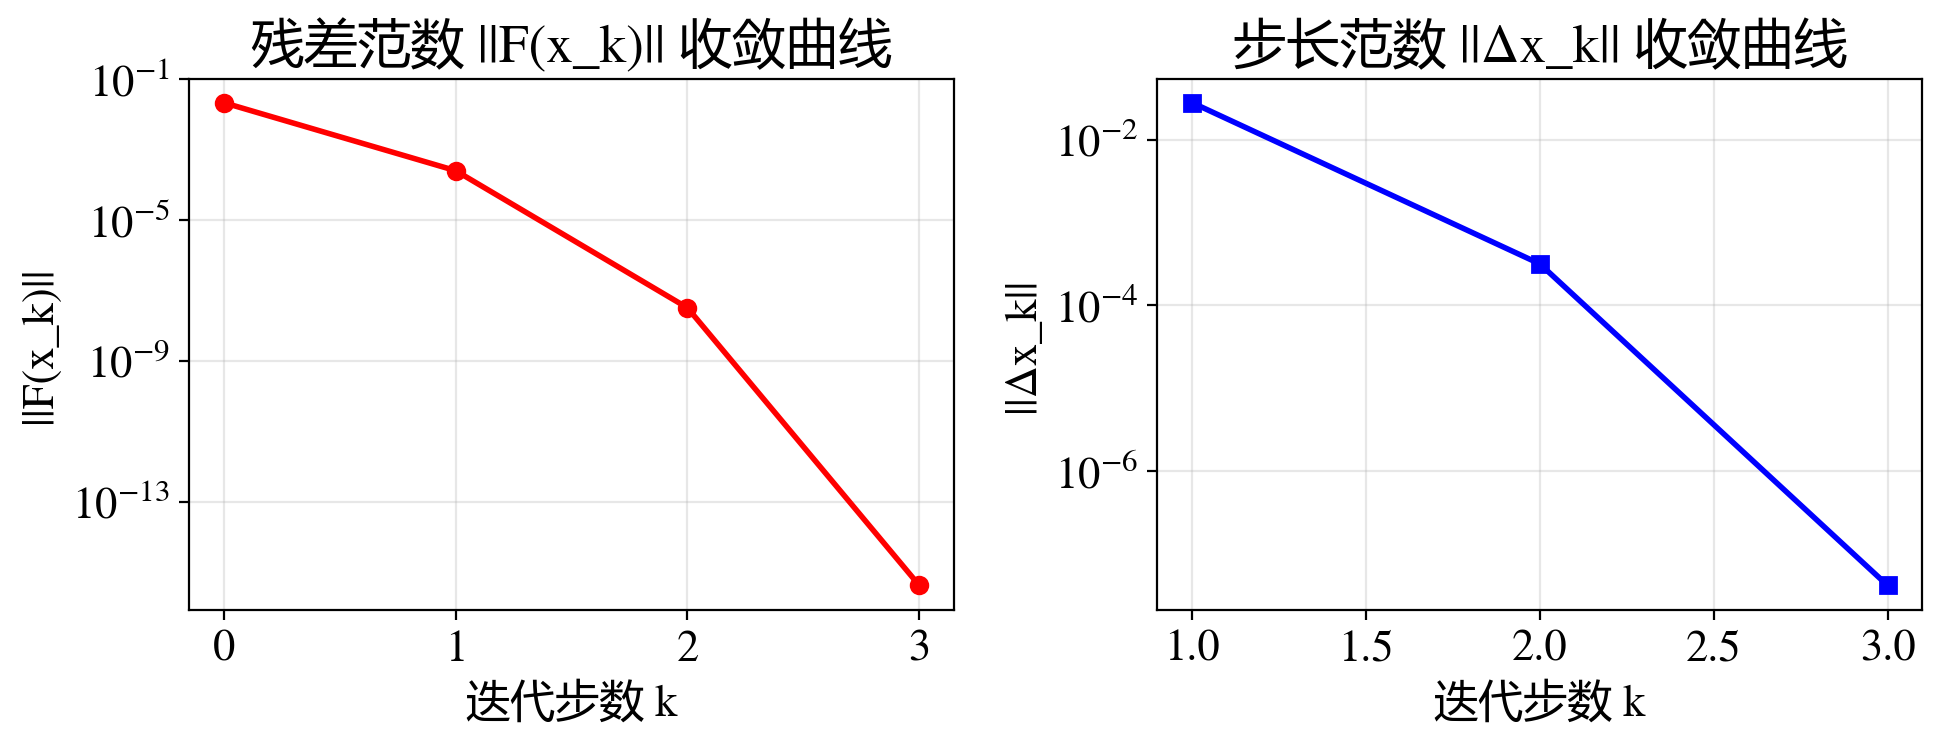


迭代历史:
k	x	y	||F||		步长		λ
0	0.500000	0.500000	2.15e-02	0.00e+00	1.000
1	0.526824	0.508014	2.52e-04	2.80e-02	1.000
2	0.526523	0.507920	3.19e-08	3.16e-04	1.000
3	0.526523	0.507920	4.13e-16	4.13e-08	1.000


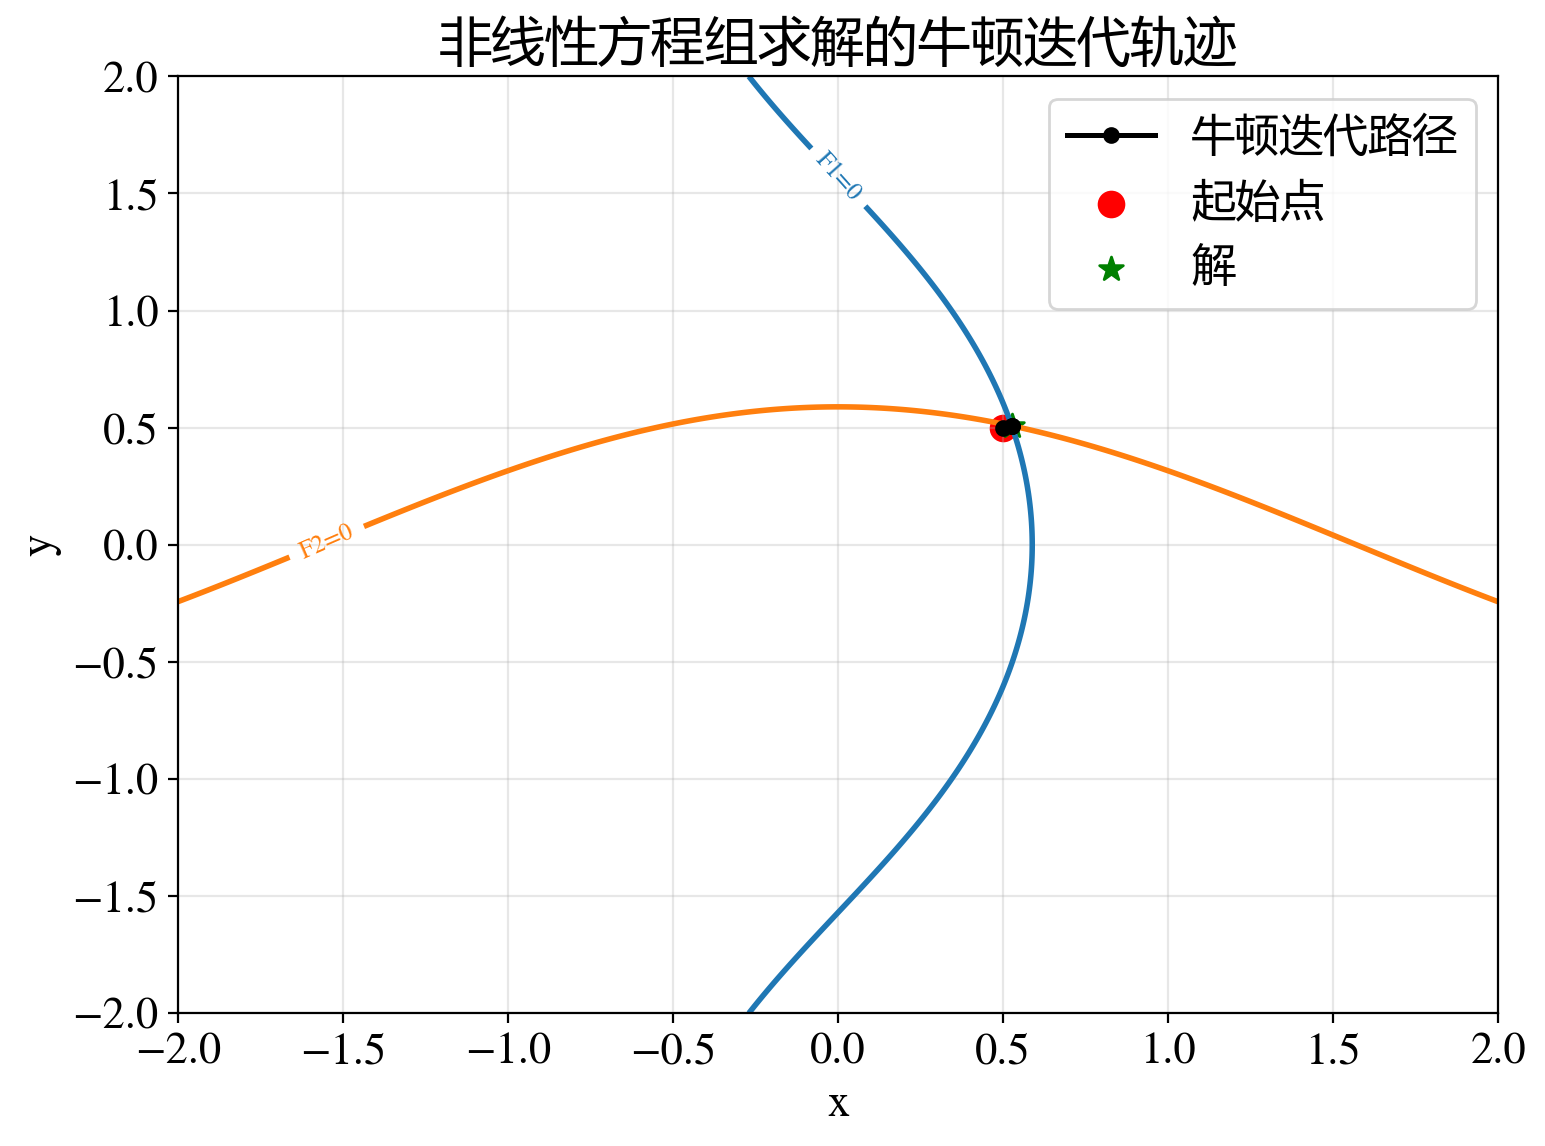

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 定义方程组
def F_fn(vec):
    x, y = vec
    return np.array([
        x - 0.7 * np.sin(x) - 0.2 * np.cos(y),    # F1
        y - 0.7 * np.cos(x) + 0.2 * np.sin(y)     # F2
    ], dtype=float)

# 定义雅可比矩阵
def J_fn(vec):
    x, y = vec
    return np.array([
        [1 - 0.7 * np.cos(x), 0.2 * np.sin(y)],    # ∂F1/∂x, ∂F1/∂y
        [0.7 * np.sin(x), 1 + 0.2 * np.cos(y)]     # ∂F2/∂x, ∂F2/∂y
    ], dtype=float)

# 阻尼牛顿法
def newton_system(F, J, x0, tol_f=1e-12, tol_x=1e-12, maxit=50,
                  damping=True, alpha=1e-4, beta=0.5, ls_max=10):
    """ 
    F: R^n -> R^n
    J: R^n -> R^n (n x n) (解析或数值雅可比)
    x0: 初值 (np.array)
    damping: 是否线搜索阻尼 (Armijo风格)
    alpha: Armijo参数 (0<alpha<1), 控制"足够下降"的阈值
    beta: 回溯因子 (0<beta<1)
    返回: x, history
    """ 
    x = np.array(x0, dtype=float)
    r = F(x)
    hist = [{"k":0, "x":x.copy(), "F":r.copy(), "normF":np.linalg.norm(r)}]
    
    if np.linalg.norm(r) <= tol_f:
        return x, hist
    
    for k in range(1, maxit+1):
        Jx = J(x)
        try:
            # 解 J Δ = -F
            delta = np.linalg.solve(Jx, -r)
        except np.linalg.LinAlgError:
            # 雅可比病态或者奇异：回退到最小二乘意义下的解
            delta, *_ = np.linalg.lstsq(Jx, -r, rcond=None)
        
        # 阻尼/回溯线搜索（若启用）
        lam = 1.0
        x_new = x + lam * delta
        r_new = F(x_new)
        
        if damping:
            # 目标函数: phi(x) = 0.5 * ||F(x)||^2
            phi0 = 0.5 * np.dot(r, r)
            # 一阶预测下降量（近似）: -alpha * lam * ||F||^2 （简单选择）
            cnt = 0
            while 0.5 * np.dot(r_new, r_new) > (1 - alpha * lam) * phi0 and cnt < ls_max:
                lam *= beta
                x_new = x + lam * delta
                r_new = F(x_new)
                cnt += 1
        
        # 记录
        hist.append({"k":k, "x":x_new.copy(), "F":r_new.copy(), "normF":np.linalg.norm(r_new),
                    "lam":lam, "step_norm":np.linalg.norm(lam * delta)})
        
        # 停止判断
        if np.linalg.norm(r_new) <= tol_f: # 残差足够小
            return x_new, hist
        if np.linalg.norm(lam * delta) <= tol_x: # 步长足够小
            return x_new, hist
        
        # 推进
        x, r = x_new, r_new
    
    return x, hist

# --- 求解 ---
x0 = np.array([0.5, 0.5])
sol, hist = newton_system(F_fn, J_fn, x0, tol_f=1e-12, tol_x=1e-12, 
                         maxit=30, damping=True, alpha=1e-4, beta=0.5, ls_max=8)

print(f"解: {sol}")
print(f"F(解) = {F_fn(sol)}")
print(f"残差范数: {np.linalg.norm(F_fn(sol)):.2e}")
print(f"迭代步数: {len(hist)-1}")

# --- 收敛曲线 ---
normF = [h["normF"] for h in hist]
stepN = [np.nan] + [h.get("step_norm", np.nan) for h in hist[1:]]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# 残差范数收敛曲线
ax[0].semilogy(normF, marker='o', color='red', linewidth=2, markersize=6)
ax[0].set_title("残差范数 ||F(x_k)|| 收敛曲线")
ax[0].set_xlabel("迭代步数 k")
ax[0].set_ylabel("||F(x_k)||")
ax[0].grid(True, which='both', alpha=0.3)

# 步长范数收敛曲线
ax[1].semilogy(stepN, marker='s', color='blue', linewidth=2, markersize=6)
ax[1].set_title("步长范数 ||Δx_k|| 收敛曲线")
ax[1].set_xlabel("迭代步数 k")
ax[1].set_ylabel("||Δx_k||")
ax[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

# --- 迭代历史详情 ---
print("\n迭代历史:")
print("k\tx\ty\t||F||\t\t步长\t\tλ")
for h in hist:
    step_norm = h.get('step_norm', 0)
    lam_val = h.get('lam', 1)
    print(f"{h['k']}\t{h['x'][0]:.6f}\t{h['x'][1]:.6f}\t{h['normF']:.2e}\t{step_norm:.2e}\t{lam_val:.3f}")

# --- 可视化：方程曲线和迭代轨迹 ---
xx = np.linspace(-2, 2, 400)
yy = np.linspace(-2, 2, 400)
XX, YY = np.meshgrid(xx, yy)

F1 = XX - 0.7 * np.sin(XX) - 0.2 * np.cos(YY)    # F1
F2 = YY - 0.7 * np.cos(XX) + 0.2 * np.sin(YY)    # F2

plt.figure(figsize=(8, 6))
cs1 = plt.contour(XX, YY, F1, levels=[0.0], colors='C0', linewidths=2)
cs2 = plt.contour(XX, YY, F2, levels=[0.0], colors='C1', linewidths=2)

plt.clabel(cs1, inline=True, fmt='F1=0', fontsize=9)
plt.clabel(cs2, inline=True, fmt='F2=0', fontsize=9)

# 迭代轨迹
xy = np.array([h["x"] for h in hist])
plt.plot(xy[:,0], xy[:,1], '-o', ms=5, lw=1.8, color='k', label='牛顿迭代路径')
plt.scatter([xy[0,0]], [xy[0,1]], c='r', s=80, label='起始点')
plt.scatter([xy[-1,0]], [xy[-1,1]], c='g', s=80, marker='*', label='解')

plt.xlabel("x")
plt.ylabel("y")
plt.title("非线性方程组求解的牛顿迭代轨迹")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 课后作业：(利用python的方法，或者课程的程序均可)

1. 用牛顿迭代法
* 求方程 $f(x)=x^2 - 3 = 0$ 的根，取初值 $x_0=1.5$，迭代计算出 $x_2$。
* 求方程 $f(x)=x^3 - 3x^2 + 4x - 2 = 0$ 在 $x_0=1.5$ 附近的一个实根。



In [33]:
import numpy as np

def newton_single(f, df, x0, tol=1e-12, max_iter=50):
    """单变量牛顿迭代法"""
    x = x0
    history = [x]
    
    for i in range(max_iter):
        fx = f(x)
        dfx = df(x)
        
        if abs(dfx) < 1e-15:
            print("导数接近零，可能无法收敛")
            break
            
        delta = fx / dfx
        x_new = x - delta
        history.append(x_new)
        
        if abs(delta) < tol:
            break
            
        x = x_new
    
    return x, history

# 第一个方程: f(x) = x^2 - 3 = 0
def f1(x):
    return x**2 - 3

def df1(x):
    return 2*x

x0 = 1.5
sol1, hist1 = newton_single(f1, df1, x0)

print("=== 方程1: x^2 - 3 = 0 ===")
print(f"初值 x0 = {x0}")
print(f"解: x = {sol1}")
print(f"验证: f({sol1}) = {f1(sol1)}")
print(f"迭代过程:")
for i, x in enumerate(hist1[:3]):  # 只显示前3次迭代
    print(f"  x_{i} = {x:.10f}, f(x_{i}) = {f1(x):.2e}")

=== 方程1: x^2 - 3 = 0 ===
初值 x0 = 1.5
解: x = 1.7320508075688772
验证: f(1.7320508075688772) = -4.440892098500626e-16
迭代过程:
  x_0 = 1.5000000000, f(x_0) = -7.50e-01
  x_1 = 1.7500000000, f(x_1) = 6.25e-02
  x_2 = 1.7321428571, f(x_2) = 3.19e-04


In [35]:
# 第二个方程: f(x) = x^3 - 3x^2 + 4x - 2 = 0
def f2(x):
    return x**3 - 3*x**2 + 4*x - 2

def df2(x):
    return 3*x**2 - 6*x + 4

x0 = 1.5
sol2, hist2 = newton_single(f2, df2, x0)

print("\n=== 方程2: x^3 - 3x^2 + 4x - 2 = 0 ===")
print(f"初值 x0 = {x0}")
print(f"解: x = {sol2}")
print(f"验证: f({sol2}) = {f2(sol2)}")
print(f"迭代过程:")
for i, x in enumerate(hist2):
    print(f"  x_{i} = {x:.10f}, f(x_{i}) = {f2(x):.2e}")


=== 方程2: x^3 - 3x^2 + 4x - 2 = 0 ===
初值 x0 = 1.5
解: x = 1.0
验证: f(1.0) = 0.0
迭代过程:
  x_0 = 1.5000000000, f(x_0) = 6.25e-01
  x_1 = 1.1428571429, f(x_1) = 1.46e-01
  x_2 = 1.0054945055, f(x_2) = 5.49e-03
  x_3 = 1.0000003317, f(x_3) = 3.32e-07
  x_4 = 1.0000000000, f(x_4) = 0.00e+00
  x_5 = 1.0000000000, f(x_5) = 0.00e+00



2. 求解方程组
$$
\begin{cases}
y \cos(xy) + 1 = 0, \\
\sin(x y) + x - y =  0.
\end{cases}
$$
在$(x=1, y=2)$ 附近的根。



In [43]:
def newton_system(F, J, x0, tol_f=1e-12, tol_x=1e-12, maxit=50,
                  damping=True, alpha=1e-4, beta=0.5, ls_max=10):
    """阻尼牛顿法求解方程组"""
    x = np.array(x0, dtype=float)
    r = F(x)
    hist = [{"k":0, "x":x.copy(), "F":r.copy(), "normF":np.linalg.norm(r)}]
    
    if np.linalg.norm(r) <= tol_f:
        return x, hist
    
    for k in range(1, maxit+1):
        Jx = J(x)
        try:
            delta = np.linalg.solve(Jx, -r)
        except np.linalg.LinAlgError:
            delta, *_ = np.linalg.lstsq(Jx, -r, rcond=None)
        
        # 阻尼线搜索
        lam = 1.0
        x_new = x + lam * delta
        r_new = F(x_new)
        
        if damping:
            phi0 = 0.5 * np.dot(r, r)
            cnt = 0
            while 0.5 * np.dot(r_new, r_new) > (1 - alpha * lam) * phi0 and cnt < ls_max:
                lam *= beta
                x_new = x + lam * delta
                r_new = F(x_new)
                cnt += 1
        
        hist.append({"k":k, "x":x_new.copy(), "F":r_new.copy(), "normF":np.linalg.norm(r_new),
                    "lam":lam, "step_norm":np.linalg.norm(lam * delta)})
        
        if np.linalg.norm(r_new) <= tol_f or np.linalg.norm(lam * delta) <= tol_x:
            return x_new, hist
        
        x, r = x_new, r_new
    
    return x, hist

In [45]:
# 方程组 1: 
# y*cos(xy) + 1 = 0
# sin(xy) + x - y = 0

def F_system1(vec):
    x, y = vec
    return np.array([
        y * np.cos(x*y) + 1,      # F1
        np.sin(x*y) + x - y       # F2
    ], dtype=float)

def J_system1(vec):
    x, y = vec
    return np.array([
        [-y**2 * np.sin(x*y), np.cos(x*y) - x*y * np.sin(x*y)],  # ∂F1/∂x, ∂F1/∂y
        [y * np.cos(x*y) + 1, x * np.cos(x*y) - 1]               # ∂F2/∂x, ∂F2/∂y
    ], dtype=float)

x0 = np.array([1.0, 2.0])
sol1, hist1 = newton_system(F_system1, J_system1, x0)

print("\n=== 方程组 1 ===")
print(f"初值: x={x0[0]}, y={x0[1]}")
print(f"解: x={sol1[0]:.8f}, y={sol1[1]:.8f}")
print(f"验证: F(x,y) = {F_system1(sol1)}")
print(f"残差范数: {np.linalg.norm(F_system1(sol1)):.2e}")
print(f"迭代次数: {len(hist1)-1}")


=== 方程组 1 ===
初值: x=1.0, y=2.0
解: x=1.08618678, y=1.94368519
验证: F(x,y) = [ 3.33066907e-16 -2.22044605e-16]
残差范数: 4.00e-16
迭代次数: 4




3. 求解方程组
$$
\begin{cases}
x^2 - 2 x - y + 0.5 = 0, \\
x^2 + 4 y^2 - 4 =  0.
\end{cases}
$$
在$(x=0, y=1)$ 附近的根。



In [48]:
# 方程组 2:
# x^2 - 2x - y + 0.5 = 0
# x^2 + 4y^2 - 4 = 0

def F_system2(vec):
    x, y = vec
    return np.array([
        x**2 - 2*x - y + 0.5,    # F1
        x**2 + 4*y**2 - 4        # F2
    ], dtype=float)

def J_system2(vec):
    x, y = vec
    return np.array([
        [2*x - 2, -1],           # ∂F1/∂x, ∂F1/∂y
        [2*x, 8*y]               # ∂F2/∂x, ∂F2/∂y
    ], dtype=float)

x0 = np.array([0.0, 1.0])
sol2, hist2 = newton_system(F_system2, J_system2, x0)

print("\n=== 方程组 2 ===")
print(f"初值: x={x0[0]}, y={x0[1]}")
print(f"解: x={sol2[0]:.8f}, y={sol2[1]:.8f}")
print(f"验证: F(x,y) = {F_system2(sol2)}")
print(f"残差范数: {np.linalg.norm(F_system2(sol2)):.2e}")
print(f"迭代次数: {len(hist2)-1}")


=== 方程组 2 ===
初值: x=0.0, y=1.0
解: x=-0.22221456, y=0.99380842
验证: F(x,y) = [3.05311332e-15 4.44089210e-15]
残差范数: 5.39e-15
迭代次数: 4




4. 求解方程组
$$
\begin{cases}
x^2 + 4 y^2 - 9 = 0, \\
-14 x^2 + 18 y + 45 =  0.
\end{cases}
$$
的根。

In [51]:
# 方程组 3:
# x^2 + 4y^2 - 9 = 0
# -14x^2 + 18y + 45 = 0

def F_system3(vec):
    x, y = vec
    return np.array([
        x**2 + 4*y**2 - 9,       # F1
        -14*x**2 + 18*y + 45     # F2
    ], dtype=float)

def J_system3(vec):
    x, y = vec
    return np.array([
        [2*x, 8*y],              # ∂F1/∂x, ∂F1/∂y
        [-28*x, 18]              # ∂F2/∂x, ∂F2/∂y
    ], dtype=float)

# 这个方程组可能有多个解，我们从不同的初值开始尝试
initial_guesses = [
    np.array([1.0, 1.0]),
    np.array([-1.0, 1.0]),
    np.array([1.0, -1.0]),
    np.array([-1.0, -1.0])
]

print("\n=== 方程组 3 ===")
for i, x0 in enumerate(initial_guesses):
    sol, hist = newton_system(F_system3, J_system3, x0)
    print(f"初值 {i+1}: x={x0[0]}, y={x0[1]}")
    print(f"  解: x={sol[0]:.8f}, y={sol[1]:.8f}")
    print(f"  残差: {np.linalg.norm(F_system3(sol)):.2e}")
    print(f"  迭代次数: {len(hist)-1}")
    print()


=== 方程组 3 ===
初值 1: x=1.0, y=1.0
  解: x=2.13721674, y=1.05265196
  残差: 1.42e-14
  迭代次数: 6

初值 2: x=-1.0, y=1.0
  解: x=-2.13721674, y=1.05265196
  残差: 1.42e-14
  迭代次数: 6

初值 3: x=1.0, y=-1.0
  解: x=1.20316696, y=-1.37408053
  残差: 1.78e-15
  迭代次数: 5

初值 4: x=-1.0, y=-1.0
  解: x=-1.20316696, y=-1.37408053
  残差: 1.78e-15
  迭代次数: 5

